In [ ]:
# Import the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sklearn
import time
# Import dataset
from google.colab import drive
drive.mount('/content/drive')

# Model 1.1: LSTM

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, make_scorer, matthews_corrcoef, confusion_matrix

# Read the dataset
df = pd.read_csv("Train_and_test_datast.csv", header=0, index_col=0)

# Separate features (X) and labels (y)
X = df.iloc[:, :-1].values
y = df['label'].values

# Convert labels to categorical
y = to_categorical(y)

# Split the data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp, shuffle=True)

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Convert labels to categorical
y_train_resampled = to_categorical(y_train_resampled)

# Scale the features separately for training, validation, and testing sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Reshape the input data for LSTM
X_train_scaled_lstm = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_val_scaled_lstm = np.reshape(X_val_scaled, (X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))
X_test_scaled_lstm = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Build the combined model with ANN and LSTM
model = Sequential()
model.add(LSTM(units=256, input_shape=(X_train_scaled_lstm.shape[1], X_train_scaled_lstm.shape[2]), activation='tanh', return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(LSTM(units=128, activation='tanh'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=64, activation='sigmoid'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=2, activation='sigmoid'))  # Assuming 2 classes (binary classification), adjust accordingly

# Compile the model with the specified learning rate
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_scaled_lstm, y_train_resampled, epochs=11, batch_size=64, validation_data=(X_val_scaled_lstm, y_val))

# Evaluate the model on the test set
accuracy = model.evaluate(X_test_scaled_lstm, y_test)[1]
print(f'Test Accuracy: {accuracy * 100:.2f}%')

# Evaluate the model
y_pred = model.predict(X_test_scaled_lstm)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print classification report, confusion matrix, and MCC
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_true_classes, y_pred_classes))
print("Matthews Correlation Coefficient (MCC):\n", matthews_corrcoef(y_true_classes, y_pred_classes))

Epoch 1/11
3086/3086 [==============================] - 79s 24ms/step - loss: 0.2169 - accuracy: 0.9153 - val_loss: 0.1437 - val_accuracy: 0.9508
Epoch 2/11
3086/3086 [==============================] - 71s 23ms/step - loss: 0.1040 - accuracy: 0.9629 - val_loss: 0.1402 - val_accuracy: 0.9550
Epoch 3/11
3086/3086 [==============================] - 72s 23ms/step - loss: 0.0735 - accuracy: 0.9740 - val_loss: 0.1435 - val_accuracy: 0.9564
Epoch 4/11
3086/3086 [==============================] - 71s 23ms/step - loss: 0.0584 - accuracy: 0.9797 - val_loss: 0.1448 - val_accuracy: 0.9609
Epoch 5/11
3086/3086 [==============================] - 70s 23ms/step - loss: 0.0491 - accuracy: 0.9828 - val_loss: 0.1605 - val_accuracy: 0.9605
Epoch 6/11
3086/3086 [==============================] - 74s 24ms/step - loss: 0.0449 - accuracy: 0.9845 - val_loss: 0.1620 - val_accuracy: 0.9598
Epoch 7/11
3086/3086 [==============================] - 72s 23ms/step - loss: 0.0404 - accuracy: 0.9864 - val_loss: 0.1527 -

### Test Model 1.1: LSTM

In [ ]:
import joblib
# Save the trained model using the native Keras format
model.save("lstm_trained_model.keras")
model.save('lstm_trained_model.h5')

# Save the scaler
joblib.dump(scaler, "lstm_scaler_model.joblib")

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef
from tensorflow.keras.models import load_model
import joblib
from tensorflow.keras import backend as K

# Load the trained model, providing the custom loss function
model = load_model("lstm_trained_model.keras")

# Load the scaler model
scaler = joblib.load("lstm_scaler_model.joblib")


# Read the new dataset
df3 = pd.read_csv("Test_dataset.csv", header=0, index_col=0)

# Separate features (X) and labels (y)
X_test = df3.drop(columns=['label']).values
y_test = to_categorical(df3['label'].values)

# Scale the features using the previously trained scaler
X_test_scaled = scaler.transform(X_test)

# Reshape the input data for LSTM
X_test_scaled_lstm = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Evaluate the model on the new dataset
y_pred = model.predict(X_test_scaled_lstm)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print classification report, confusion matrix, and MCC
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_true_classes, y_pred_classes))
print("Matthews Correlation Coefficient (MCC):\n", matthews_corrcoef(y_true_classes, y_pred_classes))

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


14/14 [==============================] - 1s 5ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.95       350
           1       0.71      0.82      0.76        68

    accuracy                           0.92       418
   macro avg       0.84      0.88      0.86       418
weighted avg       0.92      0.92      0.92       418

Confusion Matrix:
 [[327  23]
 [ 12  56]]
Matthews Correlation Coefficient (MCC):
 0.7143949129238097


# Model 1.2: LSTM with Focal loss


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, matthews_corrcoef, confusion_matrix
from tensorflow.keras import backend as K
import tensorflow as tf

# Define Focal Loss
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -K.sum(alpha * K.pow(1. - pt_1, gamma) * K.log(pt_1))-K.sum((1-alpha) * K.pow( pt_0, gamma) * K.log(1. - pt_0))
    return focal_loss_fixed

# Read the dataset
df = pd.read_csv("Train_and_test_datast.csv", header=0, index_col=0)

# Separate features (X) and labels (y)
X = df.iloc[:, :-1].values
y = df['label'].values

# Convert labels to categorical
y = to_categorical(y)

# Split the data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp, shuffle=True)

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Convert labels to categorical
y_train_resampled = to_categorical(y_train_resampled)

# Scale the features separately for training, validation, and testing sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Reshape the input data for LSTM
X_train_scaled_lstm = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_val_scaled_lstm = np.reshape(X_val_scaled, (X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))
X_test_scaled_lstm = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Build the combined model with ANN and LSTM
model = Sequential()
model.add(LSTM(units=256, input_shape=(X_train_scaled_lstm.shape[1], X_train_scaled_lstm.shape[2]), activation='tanh', return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(LSTM(units=128, activation='tanh'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=64, activation='tanh'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=2, activation='softmax'))  # Assuming 2 classes (binary classification), adjust accordingly

# Compile the model with the specified learning rate and focal loss
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=focal_loss(), metrics=['accuracy'])

# Train the model
model.fit(X_train_scaled_lstm, y_train_resampled, epochs=11, batch_size=64, validation_data=(X_val_scaled_lstm, y_val))

# Evaluate the model on the test set
accuracy = model.evaluate(X_test_scaled_lstm, y_test)[1]
print(f'Test Accuracy: {accuracy * 100:.2f}%')

# Evaluate the model
y_pred = model.predict(X_test_scaled_lstm)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print classification report, confusion matrix, and MCC
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_true_classes, y_pred_classes))
print("Matthews Correlation Coefficient (MCC):\n", matthews_corrcoef(y_true_classes, y_pred_classes))


Epoch 1/11
3086/3086 [==============================] - 102s 31ms/step - loss: 5.3389 - accuracy: 0.8809 - val_loss: 2.9696 - val_accuracy: 0.9398
Epoch 2/11
3086/3086 [==============================] - 78s 25ms/step - loss: 2.4017 - accuracy: 0.9488 - val_loss: 2.7368 - val_accuracy: 0.9484
Epoch 3/11
3086/3086 [==============================] - 88s 29ms/step - loss: 1.6741 - accuracy: 0.9650 - val_loss: 2.4432 - val_accuracy: 0.9586
Epoch 4/11
3086/3086 [==============================] - 77s 25ms/step - loss: 1.3031 - accuracy: 0.9739 - val_loss: 2.9313 - val_accuracy: 0.9589
Epoch 5/11
3086/3086 [==============================] - 77s 25ms/step - loss: 1.1077 - accuracy: 0.9778 - val_loss: 2.6067 - val_accuracy: 0.9592
Epoch 6/11
3086/3086 [==============================] - 75s 24ms/step - loss: 0.9306 - accuracy: 0.9816 - val_loss: 2.5400 - val_accuracy: 0.9619
Epoch 7/11
3086/3086 [==============================] - 76s 25ms/step - loss: 0.8297 - accuracy: 0.9837 - val_loss: 3.0340 

### Test Model 1.2: LSTM with Focal loss

In [ ]:
import joblib
# Save the trained model using the native Keras format
model.save("lstmf_trained_model.keras")
model.save('lstmf_trained_model.h5')
# Save the scaler
joblib.dump(scaler, "lstmf_scaler_model.joblib")

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef
from tensorflow.keras.models import load_model
import joblib
from tensorflow.keras import backend as K

# Define Focal Loss
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -K.sum(alpha * K.pow(1. - pt_1, gamma) * K.log(pt_1))-K.sum((1-alpha) * K.pow( pt_0, gamma) * K.log(1. - pt_0))
    return focal_loss_fixed

# Load the trained model, providing the custom loss function
model = load_model("lstmf_trained_model.keras", custom_objects={'focal_loss_fixed': focal_loss()})

# Load the scaler model
scaler = joblib.load("lstmf_scaler_model.joblib")


# Read the new dataset
df3 = pd.read_csv("Test_dataset.csv", header=0, index_col=0)

# Separate features (X) and labels (y)
X_test = df3.drop(columns=['label']).values
y_test = to_categorical(df3['label'].values)

# Scale the features using the previously trained scaler
X_test_scaled = scaler.transform(X_test)

# Reshape the input data for LSTM
X_test_scaled_lstm = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Evaluate the model on the new dataset
y_pred = model.predict(X_test_scaled_lstm)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print classification report, confusion matrix, and MCC
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_true_classes, y_pred_classes))
print("Matthews Correlation Coefficient (MCC):\n", matthews_corrcoef(y_true_classes, y_pred_classes))

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


14/14 [==============================] - 1s 5ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.95       350
           1       0.70      0.79      0.74        68

    accuracy                           0.91       418
   macro avg       0.83      0.86      0.85       418
weighted avg       0.92      0.91      0.91       418

Confusion Matrix:
 [[327  23]
 [ 14  54]]
Matthews Correlation Coefficient (MCC):
 0.6934862709476479


# Model 1.3: GRU

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, BatchNormalization, Dropout, GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, make_scorer, matthews_corrcoef, confusion_matrix

# Read the dataset
df = pd.read_csv("Train_and_test_datast.csv", header=0, index_col=0)

# Separate features (X) and labels (y)
X = df.iloc[:, :-1].values
y = df['label'].values

# Convert labels to categorical
y = to_categorical(y)

# Split the data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp, shuffle=True)

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Convert labels to categorical
y_train_resampled = to_categorical(y_train_resampled)

# Scale the features separately for training, validation, and testing sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Reshape the input data for LSTM
X_train_scaled_lstm = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_val_scaled_lstm = np.reshape(X_val_scaled, (X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))
X_test_scaled_lstm = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Build the combined model with ANN and LSTM
model = Sequential()
model.add(GRU(units=256, input_shape=(X_train_scaled_lstm.shape[1], X_train_scaled_lstm.shape[2]), activation='tanh', return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(GRU(units=128, activation='tanh'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=64, activation='sigmoid'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=2, activation='sigmoid'))  # Assuming 2 classes (binary classification), adjust accordingly

# Compile the model with the specified learning rate
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_scaled_lstm, y_train_resampled, epochs=11, batch_size=64, validation_data=(X_val_scaled_lstm, y_val))

# Evaluate the model on the test set
accuracy = model.evaluate(X_test_scaled_lstm, y_test)[1]
print(f'Test Accuracy: {accuracy * 100:.2f}%')

# Evaluate the model
y_pred = model.predict(X_test_scaled_lstm)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print classification report, confusion matrix, and MCC
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_true_classes, y_pred_classes))
print("Matthews Correlation Coefficient (MCC):\n", matthews_corrcoef(y_true_classes, y_pred_classes))

Epoch 1/11
3086/3086 [==============================] - 71s 21ms/step - loss: 0.2353 - accuracy: 0.9074 - val_loss: 0.1532 - val_accuracy: 0.9453
Epoch 2/11
3086/3086 [==============================] - 67s 22ms/step - loss: 0.1136 - accuracy: 0.9585 - val_loss: 0.1518 - val_accuracy: 0.9519
Epoch 3/11
3086/3086 [==============================] - 64s 21ms/step - loss: 0.0798 - accuracy: 0.9712 - val_loss: 0.1355 - val_accuracy: 0.9584
Epoch 4/11
3086/3086 [==============================] - 64s 21ms/step - loss: 0.0641 - accuracy: 0.9774 - val_loss: 0.1430 - val_accuracy: 0.9599
Epoch 5/11
3086/3086 [==============================] - 64s 21ms/step - loss: 0.0551 - accuracy: 0.9804 - val_loss: 0.1516 - val_accuracy: 0.9590
Epoch 6/11
3086/3086 [==============================] - 71s 23ms/step - loss: 0.0482 - accuracy: 0.9833 - val_loss: 0.1630 - val_accuracy: 0.9590
Epoch 7/11
3086/3086 [==============================] - 64s 21ms/step - loss: 0.0431 - accuracy: 0.9848 - val_loss: 0.1517 -

### Test Model 1.3: GRU

In [ ]:
import joblib
# Save the trained model using the native Keras format
model.save("gru_trained_model.keras")
model.save('gru_trained_model.h5')

# Save the scaler
joblib.dump(scaler, "gru_scaler_model.joblib")

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef
from tensorflow.keras.models import load_model
import joblib
from tensorflow.keras import backend as K

# Load the trained model, providing the custom loss function
model = load_model("gru_trained_model.keras")

# Load the scaler model
scaler = joblib.load("gru_scaler_model.joblib")


# Read the new dataset
df3 = pd.read_csv("Test_dataset.csv", header=0, index_col=0)

# Separate features (X) and labels (y)
X_test = df3.drop(columns=['label']).values
y_test = to_categorical(df3['label'].values)

# Scale the features using the previously trained scaler
X_test_scaled = scaler.transform(X_test)

# Reshape the input data for LSTM
X_test_scaled_lstm = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Evaluate the model on the new dataset
y_pred = model.predict(X_test_scaled_lstm)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print classification report, confusion matrix, and MCC
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_true_classes, y_pred_classes))
print("Matthews Correlation Coefficient (MCC):\n", matthews_corrcoef(y_true_classes, y_pred_classes))

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


14/14 [==============================] - 1s 7ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.94       350
           1       0.68      0.79      0.73        68

    accuracy                           0.91       418
   macro avg       0.82      0.86      0.84       418
weighted avg       0.91      0.91      0.91       418

Confusion Matrix:
 [[325  25]
 [ 14  54]]
Matthews Correlation Coefficient (MCC):
 0.6812814649750237


# Model 1.4: GRU with focal loss

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, BatchNormalization, Dropout, GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, matthews_corrcoef, confusion_matrix
from tensorflow.keras import backend as K
import tensorflow as tf

# Define Focal Loss
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -K.sum(alpha * K.pow(1. - pt_1, gamma) * K.log(pt_1))-K.sum((1-alpha) * K.pow( pt_0, gamma) * K.log(1. - pt_0))
    return focal_loss_fixed

# Read the dataset
df = pd.read_csv("Train_and_test_datast.csv", header=0, index_col=0)

# Separate features (X) and labels (y)
X = df.iloc[:, :-1].values
y = df['label'].values

# Convert labels to categorical
y = to_categorical(y)

# Split the data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp, shuffle=True)

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Convert labels to categorical
y_train_resampled = to_categorical(y_train_resampled)

# Scale the features separately for training, validation, and testing sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Reshape the input data for LSTM
X_train_scaled_lstm = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_val_scaled_lstm = np.reshape(X_val_scaled, (X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))
X_test_scaled_lstm = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Build the combined model with ANN and LSTM
model = Sequential()
model.add(GRU(units=256, input_shape=(X_train_scaled_lstm.shape[1], X_train_scaled_lstm.shape[2]), activation='tanh', return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(GRU(units=128, activation='tanh'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=64, activation='tanh'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=2, activation='softmax'))  # Assuming 2 classes (binary classification), adjust accordingly

# Compile the model with the specified learning rate and focal loss
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=focal_loss(), metrics=['accuracy'])

# Train the model
model.fit(X_train_scaled_lstm, y_train_resampled, epochs=11, batch_size=64, validation_data=(X_val_scaled_lstm, y_val))

# Evaluate the model on the test set
accuracy = model.evaluate(X_test_scaled_lstm, y_test)[1]
print(f'Test Accuracy: {accuracy * 100:.2f}%')

# Evaluate the model
y_pred = model.predict(X_test_scaled_lstm)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print classification report, confusion matrix, and MCC
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_true_classes, y_pred_classes))
print("Matthews Correlation Coefficient (MCC):\n", matthews_corrcoef(y_true_classes, y_pred_classes))

Epoch 1/11
3086/3086 [==============================] - 69s 21ms/step - loss: 6.0861 - accuracy: 0.8643 - val_loss: 3.3699 - val_accuracy: 0.9265
Epoch 2/11
3086/3086 [==============================] - 66s 21ms/step - loss: 2.6852 - accuracy: 0.9415 - val_loss: 2.8053 - val_accuracy: 0.9491
Epoch 3/11
3086/3086 [==============================] - 62s 20ms/step - loss: 1.8638 - accuracy: 0.9613 - val_loss: 3.0169 - val_accuracy: 0.9494
Epoch 4/11
3086/3086 [==============================] - 62s 20ms/step - loss: 1.4744 - accuracy: 0.9697 - val_loss: 2.6207 - val_accuracy: 0.9572
Epoch 5/11
3086/3086 [==============================] - 62s 20ms/step - loss: 1.2048 - accuracy: 0.9760 - val_loss: 3.0284 - val_accuracy: 0.9563
Epoch 6/11
3086/3086 [==============================] - 62s 20ms/step - loss: 1.0705 - accuracy: 0.9783 - val_loss: 2.9214 - val_accuracy: 0.9585
Epoch 7/11
3086/3086 [==============================] - 62s 20ms/step - loss: 0.9534 - accuracy: 0.9808 - val_loss: 2.7076 -

### Test Model 1.4: GRU with focal loss

In [ ]:
import joblib
# Save the trained model using the native Keras format
model.save("gruf_trained_model.keras")
model.save('gruf_trained_model.h5')

# Save the scaler
joblib.dump(scaler, "gruf_scaler_model.joblib")

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef
from tensorflow.keras.models import load_model
import joblib
from tensorflow.keras import backend as K

# Define Focal Loss
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -K.sum(alpha * K.pow(1. - pt_1, gamma) * K.log(pt_1))-K.sum((1-alpha) * K.pow( pt_0, gamma) * K.log(1. - pt_0))
    return focal_loss_fixed

# Load the trained model, providing the custom loss function
model = load_model("gruf_trained_model.keras", custom_objects={'focal_loss_fixed': focal_loss()})

# Load the scaler model
scaler = joblib.load("gruf_scaler_model.joblib")


# Read the new dataset
df3 = pd.read_csv("Test_dataset.csv", header=0, index_col=0)

# Separate features (X) and labels (y)
X_test = df3.drop(columns=['label']).values
y_test = to_categorical(df3['label'].values)

# Scale the features using the previously trained scaler
X_test_scaled = scaler.transform(X_test)

# Reshape the input data for LSTM
X_test_scaled_lstm = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Evaluate the model on the new dataset
y_pred = model.predict(X_test_scaled_lstm)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print classification report, confusion matrix, and MCC
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_true_classes, y_pred_classes))
print("Matthews Correlation Coefficient (MCC):\n", matthews_corrcoef(y_true_classes, y_pred_classes))

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


14/14 [==============================] - 1s 5ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94       350
           1       0.67      0.75      0.71        68

    accuracy                           0.90       418
   macro avg       0.81      0.84      0.82       418
weighted avg       0.90      0.90      0.90       418

Confusion Matrix:
 [[325  25]
 [ 17  51]]
Matthews Correlation Coefficient (MCC):
 0.6493281020616496


# Model 2: 2D CNN

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from tensorflow.keras.utils import to_categorical


# Read the dataset
df = pd.read_csv("Train_and_test_datast.csv", header=0, index_col=0)

# Separate features (X) and labels (y)
X = df.iloc[:, :-1].values
y = df['label'].values

# Reshape X to 20x20 matrix
X_reshaped = X.reshape(-1, 20, 20, 1)

# Convert labels to categorical if they are not binary
# (Assuming you have a binary classification problem, adjust if needed)
y_categorical = to_categorical(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_categorical, test_size=0.2, random_state=42, shuffle=True)

# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.5, random_state=42, shuffle=True)

# Apply SMOTE on training data only
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train.reshape(-1, 20 * 20), np.argmax(y_train, axis=1))

# Build the CNN model with batch normalization, dropout, and learning rate
model = Sequential()
model.add(Conv2D(256, kernel_size=(3, 3), activation='relu', input_shape=(20, 20, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.01))  # Adjust the dropout rate as needed
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.01))  # Adjust the dropout rate as needed
model.add(Dense(2, activation='sigmoid'))  # Adjust the output size based on the number of classes

# Compile the model with a specific learning rate
optimizer = Adam(learning_rate=0.001)  # Adjust the learning rate as needed
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=11, batch_size=32, validation_data=(X_val, y_val))

# Evaluate the model
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print classification report, confusion matrix, and MCC
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_true_classes, y_pred_classes))
print("Matthews Correlation Coefficient (MCC):\n", matthews_corrcoef(y_true_classes, y_pred_classes))


Epoch 1/11
1852/1852 [==============================] - 242s 130ms/step - loss: 0.3141 - accuracy: 0.8712 - val_loss: 0.3015 - val_accuracy: 0.8770
Epoch 2/11
1852/1852 [==============================] - 248s 134ms/step - loss: 0.2580 - accuracy: 0.8974 - val_loss: 0.2897 - val_accuracy: 0.8950
Epoch 3/11
1852/1852 [==============================] - 247s 133ms/step - loss: 0.2306 - accuracy: 0.9097 - val_loss: 0.2981 - val_accuracy: 0.9071
Epoch 4/11
1852/1852 [==============================] - 243s 131ms/step - loss: 0.2076 - accuracy: 0.9193 - val_loss: 0.2452 - val_accuracy: 0.9127
Epoch 5/11
1852/1852 [==============================] - 235s 127ms/step - loss: 0.1904 - accuracy: 0.9271 - val_loss: 0.2790 - val_accuracy: 0.9124
Epoch 6/11
1852/1852 [==============================] - 252s 136ms/step - loss: 0.1696 - accuracy: 0.9338 - val_loss: 0.2614 - val_accuracy: 0.9151
Epoch 7/11
1852/1852 [==============================] - 222s 120ms/step - loss: 0.1538 - accuracy: 0.9405 - val_

### Test Model 2: 2D CNN

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K
import joblib

import joblib
# Save the trained model using the native Keras format
model.save("2dcnn_trained_model.keras")
model.save('2dcnn_trained_model.h5')

# Save the scaler
joblib.dump(scaler, "2dcnn_scaler_model.joblib")

# Load the trained model
model = load_model("2dcnn_trained_model.keras")

# Load the scaler model
scaler = joblib.load("2dcnn_scaler_model.joblib")

# Read the new dataset
df3 = pd.read_csv("Test_dataset.csv", header=0, index_col=0)

# Separate features (X) and labels (y)
X_test = df3.drop(columns=['label']).values
y_test = to_categorical(df3['label'].values)

# Scale the features using the previously trained scaler
X_test_scaled = scaler.transform(X_test)

# Reshape the input data for 2dcnn
X_test_scaled_cnn = X_test_scaled.reshape(-1, 20, 20, 1)

# Evaluate the model on the new dataset
y_pred = model.predict(X_test_scaled_cnn)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print classification report, confusion matrix, and MCC
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_true_classes, y_pred_classes))
print("Matthews Correlation Coefficient (MCC):\n", matthews_corrcoef(y_true_classes, y_pred_classes))

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


14/14 [==============================] - 0s 16ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.98      0.91       350
           1       0.54      0.10      0.17        68

    accuracy                           0.84       418
   macro avg       0.69      0.54      0.54       418
weighted avg       0.80      0.84      0.79       418

Confusion Matrix:
 [[344   6]
 [ 61   7]]
Matthews Correlation Coefficient (MCC):
 0.18241816027455662


# Model 3: Ensemble Model

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

# Read the dataset
df = pd.read_csv("Train_and_test_datast.csv", header=0, index_col=0)

# Separate features (X) and labels (y)
X = df.iloc[:, :-1].values
y = df['label'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Apply SMOTE on training data only
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Define individual models
knn_model = KNeighborsClassifier(n_neighbors=5)
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
xgb_model = XGBClassifier()

# Train individual models
knn_model.fit(X_train_scaled, y_train_resampled)
mlp_model.fit(X_train_scaled, y_train_resampled)
xgb_model.fit(X_train_scaled, y_train_resampled)

# Create the ensemble model with a meta-model (XGBoost)
ensemble_model = VotingClassifier(estimators=[
    ('knn', knn_model),
    ('mlp', mlp_model),
    ('xgb', xgb_model)
], voting='soft')

# Train the ensemble model
ensemble_model.fit(X_train_scaled, y_train_resampled)

# Evaluate the ensemble model on the test set
y_pred_ensemble = ensemble_model.predict(X_test_scaled)

# Print classification report, confusion matrix, and MCC for the ensemble model
print("Ensemble Model - Classification Report:\n", classification_report(y_test, y_pred_ensemble))
print("Ensemble Model - Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ensemble))
print("Ensemble Model - Matthews Correlation Coefficient (MCC):\n", matthews_corrcoef(y_test, y_pred_ensemble))


Ensemble Model - Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96     24788
           1       0.75      0.88      0.81      4836

    accuracy                           0.93     29624
   macro avg       0.86      0.91      0.88     29624
weighted avg       0.94      0.93      0.93     29624

Ensemble Model - Confusion Matrix:
 [[23327  1461]
 [  559  4277]]
Ensemble Model - Matthews Correlation Coefficient (MCC):
 0.7719915789636719


### Test Model 3: Ensemble

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K
import joblib

ensmeble_trained_model = ensemble_model.fit(X_train_scaled, y_train_resampled)
import joblib

# Save the trained model to a file
model_filename = 'ensmeble_trained_model.pkl'
joblib.dump(ensmeble_trained_model, model_filename)

# Save the scaler
joblib.dump(scaler, "ensmeble_scaler_model.joblib")

# Load the saved model
model = joblib.load('/content/ensmeble_trained_model.pkl')

# Load the scaler model
scaler = joblib.load("/content/ensmeble_scaler_model.joblib")

# Read the new dataset
df3 = pd.read_csv("Test_dataset.csv", header=0, index_col=0)

# Separate features (X) and labels (y)
X_test = df3.drop(columns=['label']).values
y_test = df3['label'].values
# Scale the features using the previously trained scaler
X_test_scaled = scaler.transform(X_test)

# Reshape the input data for ensemble
X_test_scaled_ensemble = X_test_scaled

# Ensure that the model predictions are in the same format as y_test
y_pred = model.predict(X_test_scaled_ensemble)

# Print classification report, confusion matrix, and MCC
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Matthews Correlation Coefficient (MCC):\n", matthews_corrcoef(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.84      0.89       350
           1       0.50      0.81      0.61        68

    accuracy                           0.83       418
   macro avg       0.73      0.82      0.75       418
weighted avg       0.88      0.83      0.85       418

Confusion Matrix:
 [[294  56]
 [ 13  55]]
Matthews Correlation Coefficient (MCC):
 0.5422310616336762


## Final selection: GRU (Model 1.3)
GRU showed the highest accuracy on the totally unseen dataset

#### Model summary

In [ ]:
lstm = load_model("lstm_trained_model.keras")
print(lstm.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 1, 256)            672768    
                                                                 
 batch_normalization (Batch  (None, 1, 256)            1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 1, 256)            0         
                                                                 
 lstm_1 (LSTM)               (None, 128)               197120    
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 128)               0

#### Plotting the model

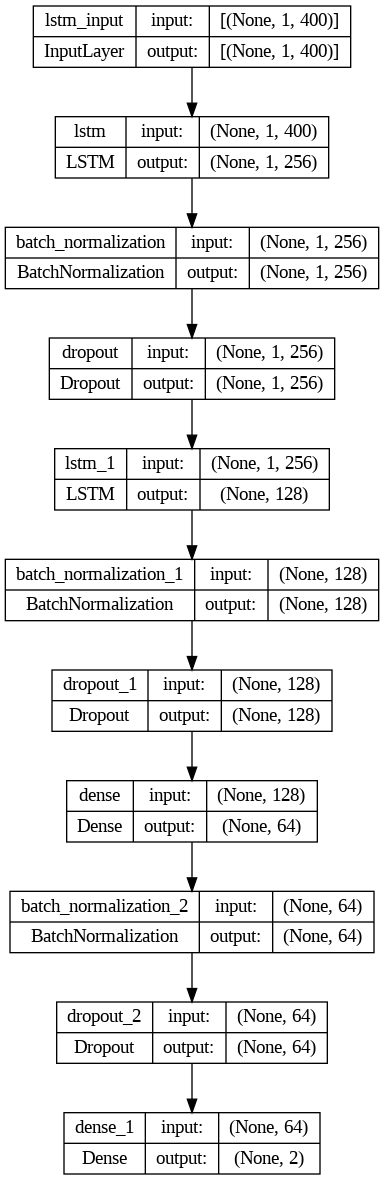

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import plot_model

# Assuming 'gru' is your Sequential model
plot_model(lstm, to_file='lstm_plot.png', show_shapes=True, show_layer_names=True)
